In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from destripe import destripe

PROCESS_SIZE = 512

img = np.array(Image.open(ROOT / "asset" / "sample_01.jpeg"))
out = destripe(img, process_size=PROCESS_SIZE)


In [2]:
def make_luma(image):
    array = np.asarray(image, dtype=np.float64)
    if array.ndim == 3 and array.shape[2] == 3:
        return array @ np.array([0.2126, 0.7152, 0.0722])
    if array.ndim == 3:
        return array[..., 0]
    return array


luma_diff = make_luma(out) - make_luma(img)
abs_luma_diff = np.abs(luma_diff)
p95, p99 = np.percentile(abs_luma_diff, [95, 99])

print(f"output: shape={out.shape}, dtype={out.dtype}")
print(f"luma difference: mean={luma_diff.mean():.4f}, std={luma_diff.std():.4f}")
print(f"absolute luma difference: p95={p95:.4f}, p99={p99:.4f}")


output: shape=(321, 517), dtype=uint8
luma difference: mean=-1.1734, std=1.4573
absolute luma difference: p95=4.0000, p99=4.0000


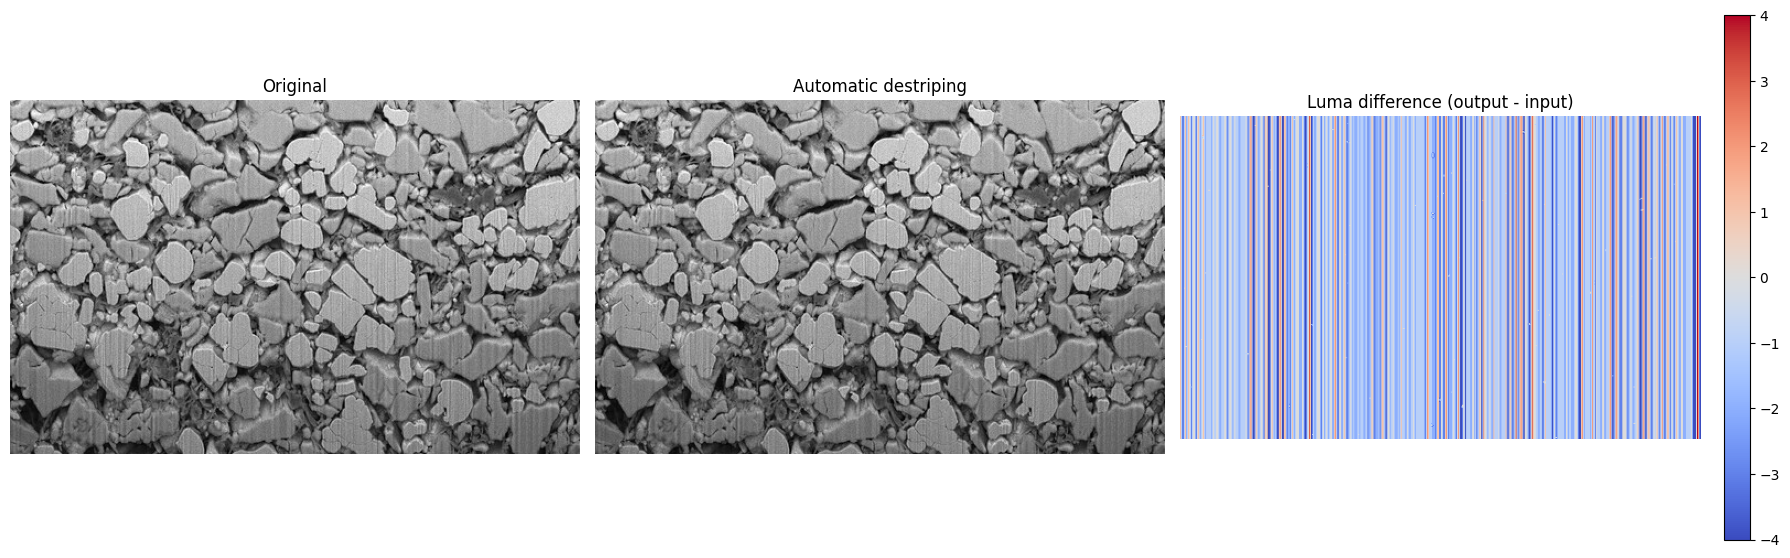

In [3]:
diff_limit = p99
if diff_limit == 0:
    diff_limit = 1

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img, cmap="gray" if img.ndim == 2 else None)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(out, cmap="gray" if out.ndim == 2 else None)
axes[1].set_title("Automatic destriping")
axes[1].axis("off")
diff_plot = axes[2].imshow(
    luma_diff,
    cmap="coolwarm",
    vmin=-diff_limit,
    vmax=diff_limit,
)
axes[2].set_title("Luma difference (output - input)")
axes[2].axis("off")
fig.colorbar(diff_plot, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
